In [5]:
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import sklearn

print("Environment working!")
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)

Environment working!
Pandas: 3.0.6
NumPy: 2.4.6
Scikit-learn: 1.9.1


In [6]:
import pandas as pd

file_path = "../data/DataCoSupplyChainDataset.csv"

df = pd.read_csv(file_path, encoding="latin1")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 180519
Columns: 53


In [7]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [8]:
print("Column names:")
for i, col in enumerate(df.columns, start=1):
    print(i, "-", col)

Column names:
1 - Type
2 - Days for shipping (real)
3 - Days for shipment (scheduled)
4 - Benefit per order
5 - Sales per customer
6 - Delivery Status
7 - Late_delivery_risk
8 - Category Id
9 - Category Name
10 - Customer City
11 - Customer Country
12 - Customer Email
13 - Customer Fname
14 - Customer Id
15 - Customer Lname
16 - Customer Password
17 - Customer Segment
18 - Customer State
19 - Customer Street
20 - Customer Zipcode
21 - Department Id
22 - Department Name
23 - Latitude
24 - Longitude
25 - Market
26 - Order City
27 - Order Country
28 - Order Customer Id
29 - order date (DateOrders)
30 - Order Id
31 - Order Item Cardprod Id
32 - Order Item Discount
33 - Order Item Discount Rate
34 - Order Item Id
35 - Order Item Product Price
36 - Order Item Profit Ratio
37 - Order Item Quantity
38 - Sales
39 - Order Item Total
40 - Order Profit Per Order
41 - Order Region
42 - Order State
43 - Order Status
44 - Order Zipcode
45 - Product Card Id
46 - Product Category Id
47 - Product Descri

In [9]:
print("Dataset shape:", df.shape)

print("\nDataset information:")
df.info()

Dataset shape: (180519, 53)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str 

In [10]:
print("Missing values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

Missing values:
Product Description              180519
Order Zipcode                    155679
Customer Lname                        8
Customer Zipcode                      3
Days for shipment (scheduled)         0
Sales per customer                    0
Benefit per order                     0
Delivery Status                       0
Late_delivery_risk                    0
Customer City                         0
Customer Country                      0
Category Id                           0
Category Name                         0
Customer Fname                        0
Customer Email                        0
Customer Password                     0
Customer Id                           0
Customer Segment                      0
Customer State                        0
Days for shipping (real)              0
dtype: int64


In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
logistics_columns = [
    col for col in df.columns
    if any(keyword in col.lower()
           for keyword in [
               "shipping", "delivery", "order",
               "late", "cost", "days",
               "region", "market", "quantity"
           ])
]

print("Potential logistics-related columns:\n")

for col in logistics_columns:
    print("-", col)

Potential logistics-related columns:

- Days for shipping (real)
- Days for shipment (scheduled)
- Benefit per order
- Delivery Status
- Late_delivery_risk
- Market
- Order City
- Order Country
- Order Customer Id
- order date (DateOrders)
- Order Id
- Order Item Cardprod Id
- Order Item Discount
- Order Item Discount Rate
- Order Item Id
- Order Item Product Price
- Order Item Profit Ratio
- Order Item Quantity
- Order Item Total
- Order Profit Per Order
- Order Region
- Order State
- Order Status
- Order Zipcode
- shipping date (DateOrders)
- Shipping Mode


In [13]:
print(df["Late_delivery_risk"].value_counts())

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64


In [14]:
on_time_count = (df["Late_delivery_risk"] == 0).sum()
total_shipments = len(df)

on_time_rate = (on_time_count / total_shipments) * 100

print("Total shipments:", total_shipments)
print("On-time shipments:", on_time_count)
print("On-time delivery rate:", round(on_time_rate, 2), "%")

Total shipments: 180519
On-time shipments: 81542
On-time delivery rate: 45.17 %


In [15]:
avg_actual_days = df["Days for shipping (real)"].mean()
avg_scheduled_days = df["Days for shipment (scheduled)"].mean()

print("Average actual shipping time:",
      round(avg_actual_days, 2), "days")

print("Average scheduled shipping time:",
      round(avg_scheduled_days, 2), "days")

Average actual shipping time: 3.5 days
Average scheduled shipping time: 2.93 days


In [16]:
shipping_delay = avg_actual_days - avg_scheduled_days

print("Average deviation from schedule:",
      round(shipping_delay, 2), "days")

Average deviation from schedule: 0.57 days


In [17]:
shipping_mode_analysis = (
    df.groupby("Shipping Mode")
      .agg(
          shipments=("Order Id", "count"),
          avg_actual_days=("Days for shipping (real)", "mean"),
          avg_scheduled_days=("Days for shipment (scheduled)", "mean"),
          late_risk_rate=("Late_delivery_risk", "mean")
      )
      .reset_index()
)

shipping_mode_analysis["late_risk_rate"] *= 100

shipping_mode_analysis = shipping_mode_analysis.round(2)

shipping_mode_analysis

,Shipping Mode,shipments,avg_actual_days,avg_scheduled_days,late_risk_rate
0,First Class,27814,2.00,1.0,95.32
1,Same Day,9737,0.48,0.0,45.74
2,Second Class,35216,3.99,2.0,76.63
3,Standard Class,107752,4.00,4.0,38.07


In [18]:
region_analysis = (
    df.groupby("Order Region")
      .agg(
          shipments=("Order Id", "count"),
          avg_shipping_days=("Days for shipping (real)", "mean"),
          late_risk_rate=("Late_delivery_risk", "mean"),
          total_sales=("Order Item Total", "sum")
      )
      .reset_index()
)

region_analysis["late_risk_rate"] = (
    region_analysis["late_risk_rate"] * 100
)

region_analysis = region_analysis.round({
    "avg_shipping_days": 2,
    "late_risk_rate": 2,
    "total_sales": 2
})

region_analysis = region_analysis.sort_values(
    "late_risk_rate",
    ascending=False
)

region_analysis

,Order Region,shipments,avg_shipping_days,late_risk_rate,total_sales
2,Central Africa,1677,3.56,57.96,292912.56
13,South Asia,7731,3.50,56.27,1397364.57
5,East Africa,1852,3.51,55.94,338054.31
22,Western Europe,27109,3.50,55.85,5296002.89
14,South of USA,4045,3.49,55.77,706904.34
8,Eastern Europe,3920,3.50,55.66,696307.19
6,East of USA,6915,3.50,55.66,1231955.13
15,Southeast Asia,9539,3.50,55.53,1738553.44
4,Central Asia,553,3.42,55.33,97953.69
20,West Asia,6009,3.49,55.28,1056080.99


In [19]:
region_analysis.head(10)

,Order Region,shipments,avg_shipping_days,late_risk_rate,total_sales
2,Central Africa,1677,3.56,57.96,292912.56
13,South Asia,7731,3.50,56.27,1397364.57
5,East Africa,1852,3.51,55.94,338054.31
22,Western Europe,27109,3.50,55.85,5296002.89
14,South of USA,4045,3.49,55.77,706904.34
8,Eastern Europe,3920,3.50,55.66,696307.19
6,East of USA,6915,3.50,55.66,1231955.13
15,Southeast Asia,9539,3.50,55.53,1738553.44
4,Central Asia,553,3.42,55.33,97953.69
20,West Asia,6009,3.49,55.28,1056080.99


In [20]:
print("Total orders:", df["Order Id"].nunique())
print("Total order items:", len(df))
print("Total quantity sold:", df["Order Item Quantity"].sum())
print("Total sales:", round(df["Order Item Total"].sum(), 2))

Total orders: 65752
Total order items: 180519
Total quantity sold: 384079
Total sales: 33054402.38


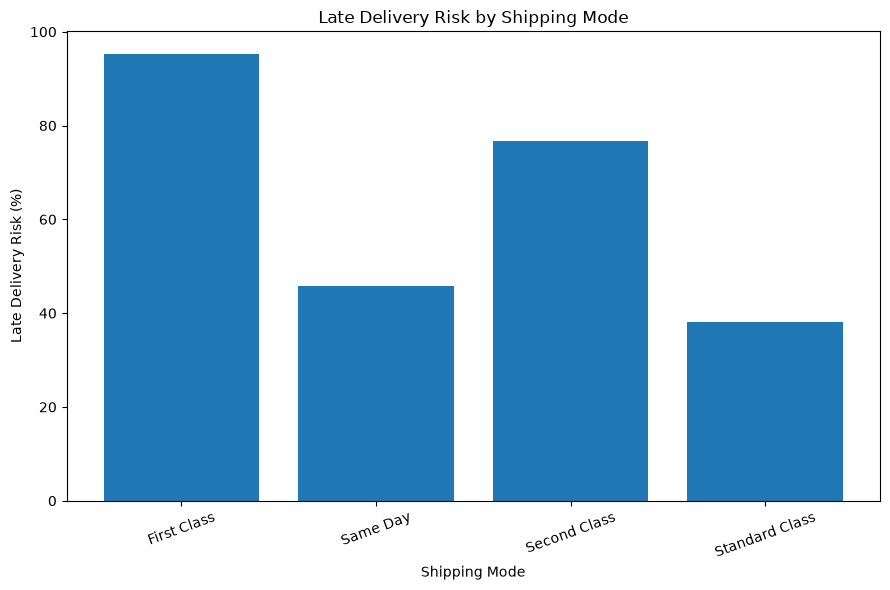

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.bar(
    shipping_analysis["Shipping Mode"],
    shipping_analysis["late_risk_rate"]
)

plt.title("Late Delivery Risk by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Late Delivery Risk (%)")

plt.xticks(rotation=20)

plt.tight_layout()

# Save the chart
plt.savefig(
    "../visualizations/late_delivery_risk_by_shipping_mode.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

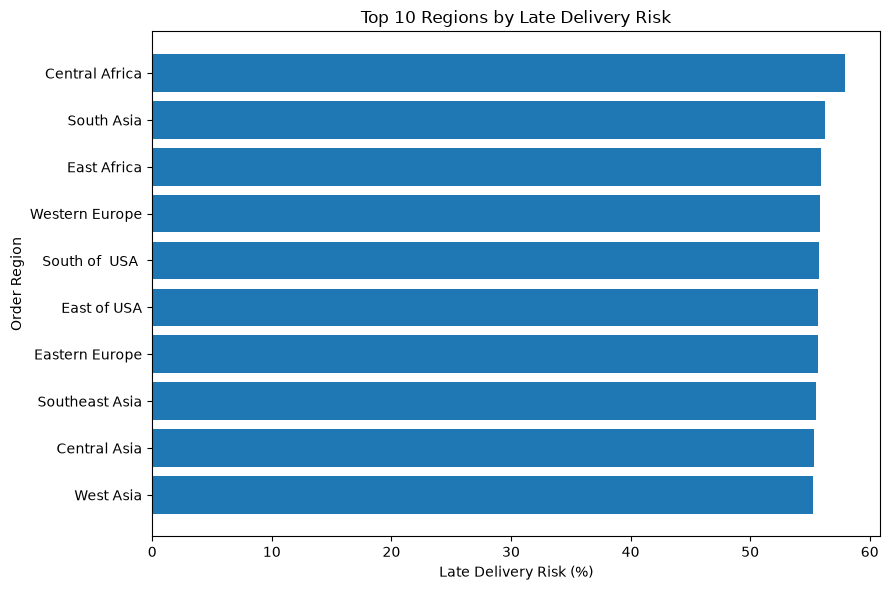

In [26]:
plt.figure(figsize=(9, 6))

top_regions = region_analysis.head(10).sort_values(
    "late_risk_rate"
)

plt.barh(
    top_regions["Order Region"],
    top_regions["late_risk_rate"]
)

plt.title("Top 10 Regions by Late Delivery Risk")
plt.xlabel("Late Delivery Risk (%)")
plt.ylabel("Order Region")

plt.tight_layout()

# Save the chart
plt.savefig(
    "../visualizations/top_10_regions_by_late_delivery_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Orders",
        "Total Order Records",
        "Total Quantity Sold",
        "Total Sales",
        "Average Actual Shipping Time",
        "Average Scheduled Shipping Time",
        "Average Schedule Deviation",
        "On-Time Delivery Rate"
    ],
    "Value": [
        df["Order Id"].nunique(),
        len(df),
        df["Order Item Quantity"].sum(),
        df["Order Item Total"].sum(),
        round(df["Days for shipping (real)"].mean(), 2),
        round(df["Days for shipment (scheduled)"].mean(), 2),
        round(
            df["Days for shipping (real)"].mean()
            - df["Days for shipment (scheduled)"].mean(),
            2
        ),
        round(
            (df["Late_delivery_risk"] == 0).mean() * 100,
            2
        )
    ]
})

kpi_summary

,KPI,Value
0,Total Orders,6.575200e+04
1,Total Order Records,1.805190e+05
2,Total Quantity Sold,3.840790e+05
3,Total Sales,3.305440e+07
4,Average Actual Shipping Time,3.500000e+00
5,Average Scheduled Shipping Time,2.930000e+00
6,Average Schedule Deviation,5.700000e-01
7,On-Time Delivery Rate,4.517000e+01


# Week 1 — Strategic Planning & Data Exploration: Key Findings

## Key Findings

1. The dataset contains 65,752 unique orders and 180,519 order records.
2. Total quantity sold is 384,079 units, with total sales of approximately 33.05 million.
3. Average actual shipping time is 3.50 days compared with an average scheduled time of 2.93 days.
4. Shipments therefore take approximately 0.57 days longer than scheduled on average.
5. First Class shipping has the highest late-delivery risk at approximately 95.32%.
6. Second Class shipping also shows a high late-delivery risk of approximately 76.63%.
7. Standard Class has a lower late-delivery risk of approximately 38.07%.
8. Central Africa has the highest regional late-delivery risk among the analyzed regions at approximately 57.96%.
9. South Asia and East Africa also show relatively high late-delivery risk.
10. These findings indicate that delivery scheduling and shipping-mode performance should be investigated further.

## Strategic Focus for Week 2

The next phase will focus on data quality assessment, missing-value treatment, duplicate detection, data-type validation, and preprocessing to prepare the dataset for deeper analysis and predictive modeling.